# Homework 06: Decision Trees

#### Due Date: Sunday, October 11th at 11:59pm (with 2 hour plus 1 minute grace period)

#### The late policy is described in the DX 603 Syllabus.

### Introduction

In the previous homework, we used logistic regression for **binary classification** and evaluated models using metrics such as accuracy, TPR, FPR, and ROC AUC. In this homework, we turn to a fundamentally different type of model: **decision trees**.

Decision trees can capture nonlinear relationships and interactions between variables, but they also introduce several hyperparameters that control model complexity. We will use the **UCI MAGIC Gamma Telescope** dataset to explore how these choices affect training and cross-validation performance.

In this homework, you will:

- Establish a **Logistic Regression baseline** for comparison.
- Explore the effects of `max_depth`, `min_samples_leaf`, and `min_samples_split` using validation curves.
- Compare **training and cross-validation performance** to identify underfitting and overfitting.
- Explore combinations of hyperparameters to see how their effects can **interact**.
- Investigate **cost-complexity pruning** using `ccp_alpha`.
- Compare the best **pre-pruned** and **cost-complexity-pruned** decision trees.
- Compare candidate models using **cross-validated ROC curves**.
- Select a final model using cross-validation, refit it on the complete development set, and evaluate it once on the untouched test set.

Decision trees are the first models we have studied with several important hyperparameters that can interact with one another. This makes model selection more challenging because we are no longer choosing among values of just one setting.

In this homework, we will begin **exploring this hyperparameter space manually.** You will first vary individual hyperparameters, then investigate combinations of promising values. This will help you see how different settings affect model complexity, underfitting, overfitting, and generalization.

Next week, when we study ensemble methods, we will introduce automated hyperparameter search to explore larger parameter spaces more efficiently. The manual exploration in this homework will provide the intuition needed to understand and use those methods effectively.

As in previous homeworks, the **test set should remain untouched during model development**. Cross-validation on the development set will be used to tune hyperparameters and compare candidate models. The test set will be used only once, after the final model has been selected.

> You are **not expected to write every scikit-learn model or evaluation procedure from scratch**. Reuse and adapt code from the Week 5 and Week 6 Coding Notebooks, and use AI to help you generate or modify code when appropriate. You are responsible for **understanding** the code, running the code, checking that it follows the instructions, and interpreting the results.

### Grading

- All homeworks in DX 603 are worth **80 points**.
- Problems 1–7 contain the coding and model-analysis portions of the homework.
- Problem 8 is a **multiple-choice** problem.
- Problem 9 is a **reflection** problem.
- Problem 5 is worth 8 points and all the other problems are worth 9 points. 
- Multi-part problems will have approximately equal points for each subpart.

You may submit a regrade request on Gradescope after your grades are released. The instructor will review the request and make any appropriate adjustment.

In [1]:
# Useful imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone

from sklearn.model_selection import (
    train_test_split,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


# --------------------------------------------------
# Globals
# --------------------------------------------------

random_seed = 42

In [2]:

# --------------------------------------------------
# Load the MAGIC Gamma Telescope dataset
# --------------------------------------------------

url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "magic/magic04.data"
)

column_names = [
    "fLength",
    "fWidth",
    "fSize",
    "fConc",
    "fConc1",
    "fAsym",
    "fM3Long",
    "fM3Trans",
    "fAlpha",
    "fDist",
    "class"
]

df = pd.read_csv(
    url,
    names=column_names
)

# Separate predictors and target
X = df.drop(columns="class")

# gamma = 1, hadron = 0
y = (df["class"] == "g").astype(int)

# --------------------------------------------------
# Development / Test Split
# --------------------------------------------------

random_seed = 42

X_development, X_test, y_development, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    stratify=y,
    random_state=random_seed
)

print("Development set:", X_development.shape)
print("Test set:       ", X_test.shape)

print("\nTarget proportions:")
print(y.value_counts(normalize=True).sort_index())

Development set: (17118, 10)
Test set:        (1902, 10)

Target proportions:
class
0    0.35163
1    0.64837
Name: proportion, dtype: float64


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fLength   19020 non-null  float64
 1   fWidth    19020 non-null  float64
 2   fSize     19020 non-null  float64
 3   fConc     19020 non-null  float64
 4   fConc1    19020 non-null  float64
 5   fAsym     19020 non-null  float64
 6   fM3Long   19020 non-null  float64
 7   fM3Trans  19020 non-null  float64
 8   fAlpha    19020 non-null  float64
 9   fDist     19020 non-null  float64
 10  class     19020 non-null  object 
dtypes: float64(10), object(1)
memory usage: 1.6+ MB


> **Note:** The only categorical column is `class,` which is the target rather than a predictor. We convert it to a binary target with gamma events coded as 1 and hadron events coded as 0. All predictor variables are numeric, so no categorical feature encoding is needed.

In [4]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


Number of predictors: 10

Target counts:
class
g    12332
h     6688
Name: count, dtype: int64

Target proportions:
class
g    0.64837
h    0.35163
Name: proportion, dtype: float64

Missing values by predictor:
No missing values.

Numeric predictor summaries:


,count,mean,std,min,25%,50%,75%,max
fLength,19020.00,53.25,42.36,4.28,24.34,37.15,70.12,334.18
fWidth,19020.00,22.18,18.35,0.00,11.86,17.14,24.74,256.38
fSize,19020.00,2.83,0.47,1.94,2.48,2.74,3.10,5.32
fConc,19020.00,0.38,0.18,0.01,0.24,0.35,0.50,0.89
fConc1,19020.00,0.21,0.11,0.00,0.13,0.20,0.29,0.68
fAsym,19020.00,-4.33,59.21,-457.92,-20.59,4.01,24.06,575.24
fM3Long,19020.00,10.55,51.00,-331.78,-12.84,15.31,35.84,238.32
fM3Trans,19020.00,0.25,20.83,-205.89,-10.85,0.67,10.95,179.85
fAlpha,19020.00,27.65,26.10,0.00,5.55,17.68,45.88,90.00
fDist,19020.00,193.82,74.73,1.28,142.49,191.85,240.56,495.56


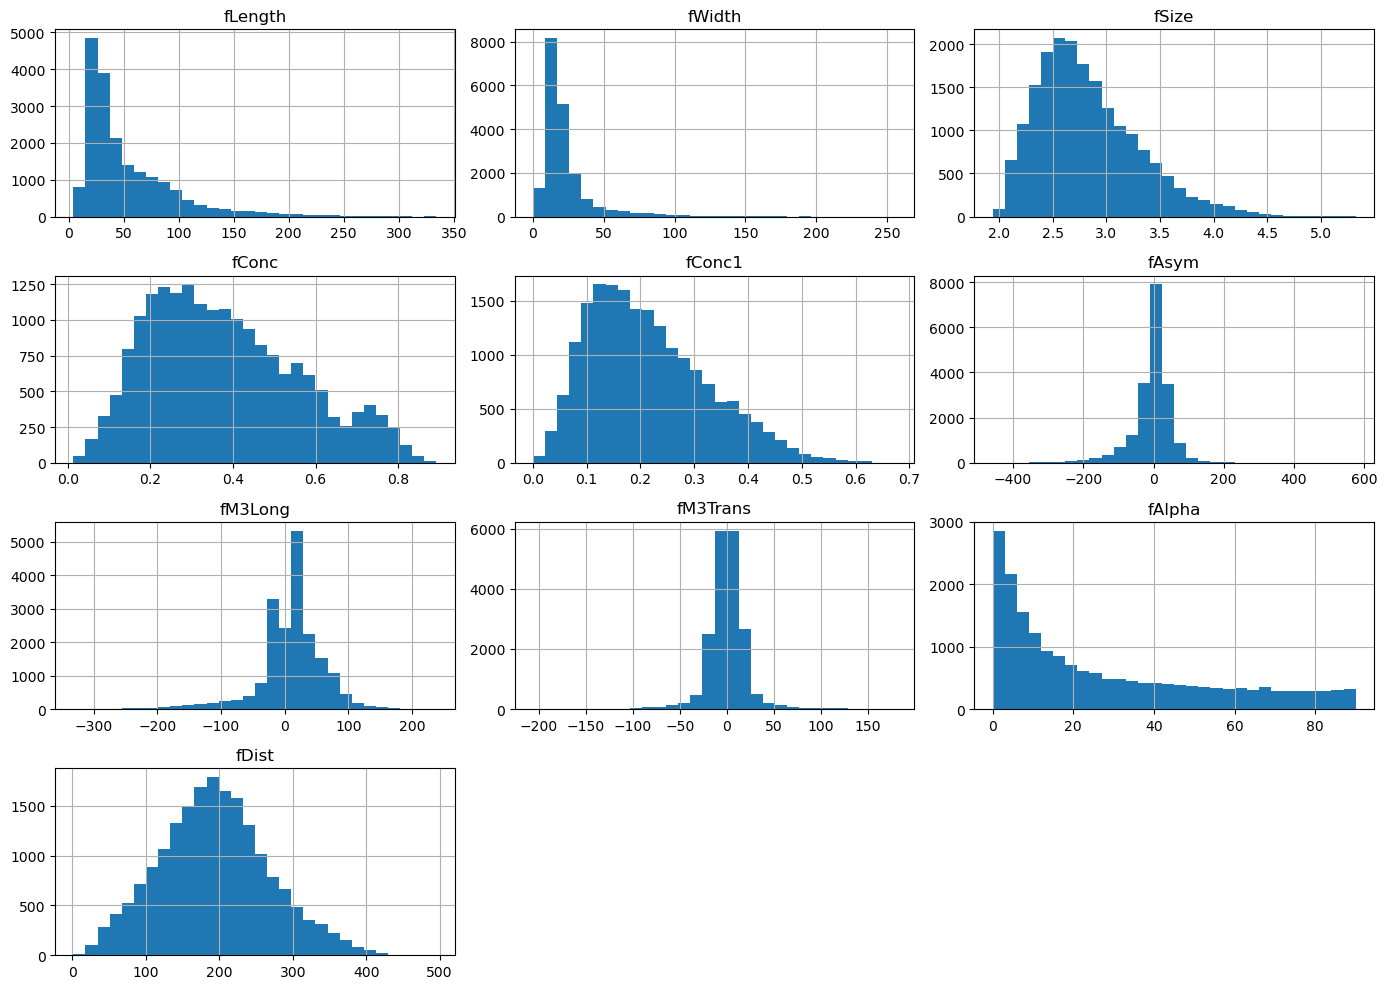

In [5]:
# --------------------------------------------------
# Basic EDA
# --------------------------------------------------

# All predictors are numeric
numeric_cols = df.drop(columns="class").columns

print("Number of predictors:", len(numeric_cols))


# --------------------------------------------------
# Target distribution
# --------------------------------------------------

print("\nTarget counts:")
print(df["class"].value_counts())

print("\nTarget proportions:")
print(df["class"].value_counts(normalize=True))


# --------------------------------------------------
# Missing values
# --------------------------------------------------

print("\nMissing values by predictor:")
missing_counts = df[numeric_cols].isna().sum()

if missing_counts.sum() == 0:
    print("No missing values.")
else:
    print(missing_counts[missing_counts > 0])


# --------------------------------------------------
# Numeric predictor summaries
# --------------------------------------------------

print("\nNumeric predictor summaries:")

display(
    df[numeric_cols]
    .describe()
    .T
    .style.format("{:.2f}")
)


# --------------------------------------------------
# Histograms of numeric predictors
# --------------------------------------------------

df[numeric_cols].hist(
    bins=30,
    figsize=(14, 10)
)

plt.tight_layout()
plt.show()

## Problem 1 — Logistic Regression Baseline

Using the **Week 5 coding notebook** as a guide, build a Logistic Regression baseline for the MAGIC Gamma Telescope dataset.

Using the Week 5 and Week 6 coding notebooks as guides, create:
- a StandardScaler + LogisticRegression pipeline named logistic_model
- a 5-fold, 5-repeat RepeatedStratifiedKFold object named repeated_cv, using random_seed

Using the **development set only**:

- Use repeated cross-validation to compute:
  - mean ROC AUC
  - mean accuracy
- Fit the Logistic Regression model on the complete development set.
- Compute:
  - training ROC AUC
  - training accuracy

Display all four values, rounded to four decimal places.

Do **not** use the test set in this problem.

Store your answer in:

```python
a1 = ...
```

where `a1` is the **mean cross-validation ROC AUC** for the Logistic Regression baseline.


In [6]:
# Your code here, add additional cells as needed


In [7]:
# Your answer here, NOT in the next cell

a1 = 0      # Replace with the mean cross-validation ROC AUC

In [8]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a1 = {a1:,.4f}')

a1 = 0.0000


## Problem 2 — Explore Decision-Tree Hyperparameters

Decision trees provide several hyperparameters for controlling model complexity. In this problem, you will investigate three of them separately before exploring combinations in the next problem.

### Part A — `max_depth`

Using the decision-tree sweep pattern from the Week 6 coding notebook, investigate how `max_depth` affects model performance.

For each value in

```python
depth_values = range(1, 21)
```

do the following:

- Build a `DecisionTreeClassifier` using that value of `max_depth`.
- Use repeated cross-validation on the development set to compute:
  - mean ROC AUC
  - mean accuracy
- Fit the model on the complete development set and compute its training ROC AUC.
- Store the results for all values of `max_depth`.
- Plot **training AUC and mean CV AUC** versus `max_depth`.
- Plot **mean CV accuracy** versus `max_depth`.
- Identify the value of `max_depth` with the highest mean CV AUC.

Store your answer in:

```python
a2a = ...
```

where `a2a` is the selected value of `max_depth`.


In [9]:
# Your code here, as more cells as needed



In [10]:
# Your answer here, NOT in the next cell

a2a = 0      # Replace with the selected value of `max_depth`.

In [11]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a2a = {a2a}')

a2a = 0


### Part B — `min_samples_leaf`

Using the same general sweep procedure as in Part A, investigate how `min_samples_leaf` affects model performance.

Choose a reasonable range of values for `min_samples_leaf` that includes both small and substantially larger leaf sizes.

For each value:

- Build a `DecisionTreeClassifier` using that value of `min_samples_leaf`.
- Use repeated cross-validation on the development set to compute:
  - mean ROC AUC
  - mean accuracy
- Fit the model on the complete development set and compute its training ROC AUC.
- Store the results.
- Plot **training AUC and mean CV AUC** versus `min_samples_leaf`.
- Plot **mean CV accuracy** versus `min_samples_leaf`.
- Identify the value with the highest mean CV AUC.

Store your answer in:

```python
a2b = ...
```

where `a2b` is the selected value of `min_samples_leaf`.

**Hint:** Since useful values may span a fairly wide range, a roughly multiplicative sequence such as 1, 2, 5, 10, 20, 50, … may be helpful.

In [12]:
# Your code here, add as many cells as you need



In [13]:
# Your answer here, NOT in the next cell

a2b = 0      # Replace with the selected value of min_samples_leaf.

In [14]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a2b = {a2b}')

a2b = 0


### Part C — `min_samples_split`

Repeat the same type of analysis for `min_samples_split`.

Choose a reasonable range of values that includes both small and substantially larger split thresholds.

For each value:

- Build a `DecisionTreeClassifier` using that value of `min_samples_split`.
- Use repeated cross-validation on the development set to compute:
  - mean ROC AUC
  - mean accuracy
- Fit the model on the complete development set and compute its training ROC AUC.
- Store the results.
- Plot **training AUC and mean CV AUC** versus `min_samples_split`.
- Plot **mean CV accuracy** versus `min_samples_split`.
- Identify the value with the highest mean CV AUC.

Store your answer in:

```python
a2c = ...
```

where `a2c` is the selected value of `min_samples_split`.

**Hint:** As with `min_samples_leaf`, it may be useful to test values over a broad range rather than only values close to the default.


In [15]:
# Your code here, add as many cells as you need



In [16]:
# Your answer here, NOT in the next cell

a2c = 0      # Replace with the selected value of `min_samples_split`.

In [17]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a2c = {a2c}')

a2c = 0


## Problem 3 — Explore Hyperparameter Interactions

In Problem 2, you tuned `max_depth`, `min_samples_leaf`, and `min_samples_split` separately. However, the best value of one hyperparameter may depend on the settings of the others.

In this problem, investigate combinations of `min_samples_leaf` and `min_samples_split`.

Use:

```python
leaf_values = [5, 15, 30, 50]
split_values = [50, 100, 150, 200, 300]
```

For every combination of `min_samples_leaf` and `min_samples_split`:

- Build a `DecisionTreeClassifier` using both hyperparameter values.
- Use repeated cross-validation on the development set to compute:
  - mean ROC AUC
  - mean accuracy
- Fit the model on the complete development set and compute its training ROC AUC.
- Store the results in a table.
- Identify the combination with the highest mean CV AUC.

Store your answers in:

```python
a3a = ...
a3b = ...
```

where:

- `a3a` is the selected value of `min_samples_leaf`
- `a3b` is the selected value of `min_samples_split`



In [18]:
# Your code here, add as many cells as you wish


In [19]:
# Your answer here, NOT in the next cell

a3a = 0      # Replace with the selected value of `min_samples_leaf` for problem 3

In [20]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a3a = {a3a}')

a3a = 0


In [21]:
# Your answer here, NOT in the next cell

a3b = 0      # Replace with the selected value of `min_samples_split` for problem 3

In [22]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a3b = {a3b}')

a3b = 0


## Problem 4 — Tune `ccp_alpha`

Use **cost-complexity pruning** to investigate another way of controlling decision-tree complexity.

For this problem, test the following range of pruning values:

```python
alpha_values = np.linspace(
    0.00015,
    0.00080,
    30
)
```

For each value of `ccp_alpha`:

- Build a `DecisionTreeClassifier` using that value.
- Use repeated cross-validation on the development set to compute:
  - mean ROC AUC
  - mean accuracy
- Fit the model on the complete development set.
- Compute the training ROC AUC.
- Store the results.

Then:

- Plot training AUC and mean CV AUC versus `ccp_alpha`.
- Plot mean CV accuracy separately.
- Determine which value of `ccp_alpha` produces the highest mean CV AUC.

Use **mean CV AUC** to select the best pruning value.

Store your answer in:

```python
a4 = ...
```

where `a4` is the selected value of `ccp_alpha`.

In [23]:
# Your code here, add as many cells as you wish



In [24]:
# Your answer here, NOT in the next cell

a4 = 0      # Replace with the selected value of `ccp_alpha`

In [25]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4 = {a4}')

a4 = 0


## Problem 5 — Compare Pre-Pruning and Cost-Complexity Pruning

You have now explored several ways to control the complexity of a decision tree.

Compare these three candidate models:

1. The **best single-hyperparameter tree** from Problem 2.
2. The **best two-hyperparameter tree** from Problem 3.
3. The **best `ccp_alpha`-pruned tree** from Problem 4.

Create a table containing, for each candidate:

- Training ROC AUC
- Mean CV ROC AUC
- Mean CV accuracy

Use the results you have already computed in Problems 2–4; you do **not** need to repeat the cross-validation.

Select the candidate with the highest **mean CV ROC AUC**.

Store your answer in:

```python
a5 = ...
```

using one of the following strings:

```python
"single"
"combined"
"pruned"
```

where:

- `"single"` = best single-hyperparameter model from Problem 2
- `"combined"` = best two-hyperparameter model from Problem 3
- `"pruned"` = best `ccp_alpha` model from Problem 4

Do not use the test set.

In [26]:
# Your code here, add as many cells as you need



In [27]:
# Your answer here, NOT in the next cell

a5 = ""      # Replace with one of "single", "combined", or "pruned"

In [28]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a5 = {a5}')

a5 = 


## Problem 6 — Compare ROC Curves

Using the **Week 5 ROC-curve code** as a guide, compare the following models using cross-validated predictions on the development set:

- Logistic Regression baseline
- Best individually tuned decision tree from Problem 2
- Best two-parameter decision tree from Problem 3
- Best `ccp_alpha`-pruned decision tree from Problem 4

Plot all four ROC curves on the same graph and report the ROC AUC for each model in the legend.

Use a single 5-fold stratified cross-validation split for this plot:

```python
roc_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_seed
)
```

Use `cross_val_predict(..., method="predict_proba")` to obtain out-of-fold predicted probabilities for each model.

Then compute:

```python
a6 = ...
```

where `a6` is the difference between the ROC AUC of the **best decision-tree model** and the ROC AUC of Logistic Regression.



In [29]:
# Your code here, add as many cells as you wish



In [30]:
# Your answer here, NOT in the next cell

a6 = 0      # Replace with the difference between the two ROC AUC scores

In [31]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a6 = {a6:,.4f}')

a6 = 0.0000


## Problem 7 — Final Test Evaluation

Using the model selected in **Problem 5**, refit that model on the **complete development set**.

Then evaluate it **once** on the untouched test set.

Report:

- ROC AUC
- Accuracy
- F1 score
- True Positive Rate (TPR)
- False Positive Rate (FPR)

Also:

- display the confusion matrix
- plot the ROC curve for the test set

Do not use the test set to make any further model or hyperparameter choices.

Store the test ROC AUC in:

```python
a7 = ...
```


In [32]:
# Your code here, add as many cells as you wish 

In [33]:
# Your answer here, NOT in the next cell

a7 = 0      # Replace with the test ROC AUC 

In [34]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a7 = {a7:,.4f}')

a7 = 0.0000


## Problem 8 — Multiple Choice

For each question, select the **best answer**.

### Part A — Hyperparameter Interactions

In Problem 2, you tuned `min_samples_leaf` and `min_samples_split` separately. In Problem 3, you varied them together.

Why might the values that performed best when tuned separately **not** form the best combination when used together?

1. Cross-validation cannot be used when more than one hyperparameter is varied.
2. The effect of one hyperparameter can depend on the value of another hyperparameter.
3. `min_samples_leaf` and `min_samples_split` control exactly the same property of a tree.
4. The individually selected values must always give the best result when combined.

In [35]:
# Your answer here, NOT in the next cell

a8a = 0      # Replace with one of 1, 2, 3, 4

In [36]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a8a = {a8a}')

a8a = 0


### Part B — Training vs. Cross-Validation Performance

During one of the hyperparameter sweeps, increasing the amount of regularization causes **training AUC to decrease while mean CV AUC increases**.

What is the most likely explanation?

1. The model is reducing overfitting and generalizing better to unseen data.
2. The model is becoming more complex and fitting the training data more closely.
4. Cross-validation is no longer valid because training AUC decreased.
5. The model should be selected using the highest training AUC instead.

In [37]:
# Your answer here, NOT in the next cell

a8b = 0      # Replace with one of 1, 2, 3, 4

In [38]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a8b = {a8b}')

a8b = 0


### Part C — Pre-Pruning vs. Cost-Complexity Pruning

Suppose the best manually tuned combination of stopping hyperparameters has a slightly higher mean CV AUC than the best `ccp_alpha` model.

Which conclusion is most appropriate?

1. Pre-pruning is always better than cost-complexity pruning.
2. Cost-complexity pruning should never be used when stopping criteria are available.
3. For this dataset and the settings investigated, the pre-pruned model performed somewhat better according to mean CV AUC.
4. The `ccp_alpha` model must have been implemented incorrectly.

In [39]:
# Your answer here, NOT in the next cell

a8c = 0      # Replace with one of 1, 2, 3, 4

In [40]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a8c = {a8c}')

a8c = 0


### Part D — Crossing ROC Curves

In Problem 6, suppose the ROC curves for two decision-tree models cross.

What does this imply?

1. One of the ROC curves must have been calculated incorrectly.
2. The model with the larger overall AUC must have a higher TPR at every possible FPR.
3. Which model is preferable may depend on the desired operating region, even if one model has a slightly larger overall AUC.
4. The two models must have exactly the same AUC.

In [41]:
# Your answer here, NOT in the next cell

a8d = 0      # Replace with one of 1, 2, 3, 4

In [42]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a8d = {a8d}')

a8d = 0


### Part E — AUC vs. Accuracy
Suppose two decision-tree models have very similar mean CV accuracy, but one has a noticeably higher mean CV ROC AUC.
What does this suggest?
1. The model with higher AUC is necessarily more accurate at the default classification threshold.
2. Accuracy and ROC AUC measure exactly the same aspect of model performance.
3. The model with lower AUC should always be selected if its training accuracy is higher.
4. The model with higher AUC does a better job ranking positive cases above negative cases across possible thresholds.


In [43]:
# Your answer here, NOT in the next cell

a8e = 0      # Replace with one of 1, 2, 3, 4

In [44]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a8e = {a8e}')

a8e = 0


## Problem 9 — Reflection

In a short paragraph, reflect on what you learned from tuning the decision tree in this homework.

Your response should address all of the following:

- How did the different hyperparameters affect the balance between **underfitting and overfitting**?
- What did you learn from comparing hyperparameters **one at a time** with tuning them **in combination**?
- How did the best pre-pruned model compare with the best `ccp_alpha`-pruned model?
- Why is cross-validation useful for making these choices before evaluating the final model on the test set?


In [45]:
# Your answer here, NOT in the next cell

a9 = """
Write your reflection here.
"""

In [46]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print("a9 =")
print(a9)

a9 =

Write your reflection here.



### Appendix: Which `DecisionTreeClassifier` Parameters Are Most Important?

Decision trees have many hyperparameters, but some have a much greater effect on **model complexity, overfitting, and generalization** than others. When first working with decision trees, it is useful to focus on the parameters that most directly control how large and detailed the tree can become.

In this homework, we focus on four especially important complexity controls:

---

1. **`max_depth`** (default: `None`)  
   *Sets the maximum depth of the tree. Smaller values produce simpler trees that may underfit, while larger values allow more complex trees that may overfit.*

2. **`min_samples_leaf`** (default: `1`)  
   *Sets the minimum number of training samples that must remain in a leaf node. Larger values prevent very small, highly specialized leaves and can reduce overfitting.*

3. **`min_samples_split`** (default: `2`)  
   *Sets the minimum number of training samples required before an internal node is allowed to split. Larger values prevent the tree from continuing to split small groups of observations.*

4. **`ccp_alpha`** (default: `0.0`)  
   *Controls Minimal Cost-Complexity Pruning. Larger values penalize complex trees more strongly, causing more branches to be removed after the tree is grown.*

---

Other useful parameters include:

5. **`max_leaf_nodes`** (default: `None`)  
   *Limits the total number of leaf nodes in the tree. Like `max_depth`, it provides a direct way to restrict overall tree size.*

6. **`min_impurity_decrease`** (default: `0.0`)  
   *Allows a split only when it reduces impurity by at least the specified amount. Larger values therefore make the tree more conservative about creating new branches.*

7. **`criterion`** (default: `"gini"` for `DecisionTreeClassifier`)  
   *Determines how the quality of a split is measured. Common choices for classification include `"gini"` and `"entropy"`.*

8. **`splitter`** (default: `"best"`)  
   *Controls how candidate splits are selected at each node. `"best"` searches for the strongest split, while `"random"` introduces additional randomness.*

9. **`max_features`** (default: `None`)  
   *Limits the number of predictor variables considered when searching for a split. This is especially important in ensemble methods such as Random Forests.*

10. **`min_weight_fraction_leaf`** (default: `0.0`)  
    *Specifies the minimum weighted fraction of the training data that must appear in a leaf. It is mainly useful when observations have sample weights.*

11. **`random_state`** (default: `None`)  
    *Controls reproducibility when randomness is involved in fitting the tree. Setting `random_state=random_seed` makes repeated runs reproducible.*

---

For this homework, the main goal is not to explore every available setting, but to understand how a few important hyperparameters control **tree complexity**, how those hyperparameters can **interact**, and how cross-validation can be used to choose among candidate models.